<a href="https://colab.research.google.com/github/elonsobrevilla06-byte/SentimentAnalysis_SVMModel/blob/main/SentimentAnalysis_SVMModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

In [ ]:
path = kagglehub.dataset_download('abhi8923shriv/sentiment-analysis-dataset')
data_test = pd.read_csv(f"{path}/test.csv", encoding ='latin-1')
data_train = pd.read_csv(f"{path}/train.csv", encoding = 'latin-1')

data_test.head()


100%|██████████| 54.4M/54.4M [00:00<00:00, 234MB/s]

Extracting files...


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


# **Data Cleaning**

In [ ]:
df = pd.concat([data_train, data_test], ignore_index = True)
df

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797.0,27400.0,105.0
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265.0,470.0,164.0
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272.0,1246700.0,26.0
...,...,...,...,...,...,...,...,...,...,...
32291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')

In [ ]:
selected_text = df.selected_text
selected_text.head()

,selected_text
0,"I`d have responded, if I were going"
1,Sooo SAD
2,bullying me
3,leave me alone
4,"Sons of ****,"


In [ ]:
columns_to_drop = ['Time of Tweet', 'Population -2020', 'Land Area (Km²)', "Density (P/Km²)"]
df = df.drop(columns = columns_to_drop)


In [ ]:
df.isna().any(axis = None)

np.True_

In [ ]:
print(df.isnull().sum())

print(f"\nLength of Df: {len(df)}")

df = df.dropna(axis = 0)
print(f"\nLength of new Df: {len(df)}")



textID           1281
text             1282
selected_text    4816
sentiment        1281
Age of User      1281
Country          1281
dtype: int64

Length of Df: 32296

Length of new Df: 27480


## **Check Data Format Inconsistency**

- **Quick Overview**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   textID         27480 non-null  object  
 1   text           27480 non-null  object  
 2   selected_text  27480 non-null  object  
 3   sentiment      27480 non-null  category
 4   Age of User    27480 non-null  category
 5   Country        27480 non-null  object  
dtypes: category(2), object(4)
memory usage: 1.1+ MB


- **Check unique values per column**

In [ ]:
for col in df.select_dtypes(include = 'object').columns:
  print(f"\n--- {col} ---")
  print(df[col].unique()[:20])


--- textID ---
['cb774db0d1' '549e992a42' '088c60f138' '9642c003ef' '358bd9e861'
 '28b57f3990' '6e0c6d75b1' '50e14c0bb8' 'e050245fbd' 'fc2cbefa9d'
 '2339a9b08b' '16fab9f95b' '74a76f6e0a' '04dd1d2e34' 'bbe3cbf620'
 '8a939bfb59' '3440297f8b' '919fa93391' 'af3fed7fc3' '40e7becabf']

--- text ---
[' I`d have responded, if I were going'
 ' Sooo SAD I will miss you here in San Diego!!!'
 'my boss is bullying me...' ' what interview! leave me alone'
 ' Sons of ****, why couldn`t they put them on the releases we already bought'
 'http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth'
 '2am feedings for the baby are fun when he is all smiles and coos'
 'Soooo high' ' Both of you'
 ' Journey!? Wow... u just became cooler.  hehe... (is that possible!?)'
 ' as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff'
 'I really really like the song Love Story by Taylor Swift'
 'My Sharpie is running DANGERously 

- **Checking Sentiment**

In [ ]:
print(df['sentiment'].unique())
print(df['sentiment'].value_counts())
print(df['sentiment'].nunique())

['neutral' 'negative' 'positive']
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64
3


## **Exploratory Data Analysis**

In [ ]:
df.duplicated().sum()
df[df.duplicated()]


,textID,text,selected_text,sentiment,Age of User,Country


In [ ]:
df['sentiment'].value_counts(normalize = True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


<Axes: xlabel='sentiment'>

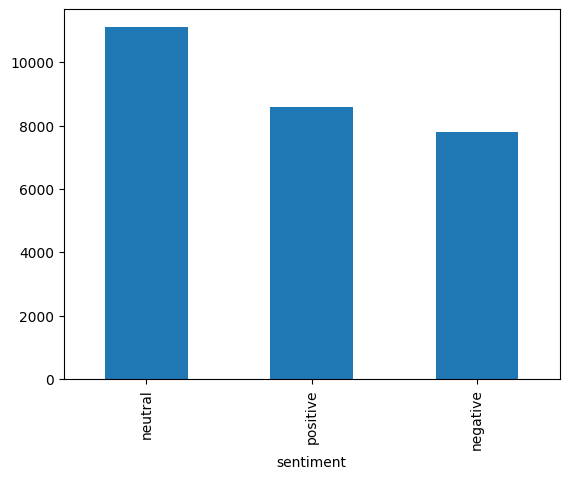

In [ ]:
df['sentiment'].value_counts().plot(kind = 'bar')

In [ ]:
df["Age of User"].dtype

dtype('O')

<Axes: >

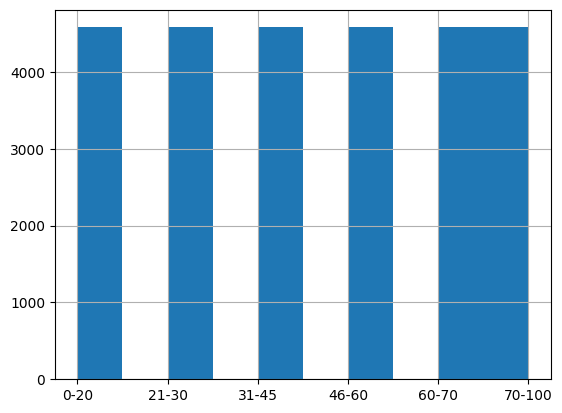

In [ ]:
df['Age of User'].hist()


- **More Data Collection and Cleaning**

In [ ]:
df['Age of User'] = df['Age of User'].astype('category')
df['sentiment'] = df['sentiment'].astype("category")

df['text'] = df['text'].str.strip()
print((df['text'] == '').sum())

df['text_len_words'] = df['text'].str.split().str.len()
print(df['text_len_words'].describe())
print(df[df['text_len_words'] <= 1])

0
count    27480.000000
mean        12.902875
std          6.925938
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: text_len_words, dtype: float64
           textID          text selected_text sentiment Age of User  \
42     2e7082d1c8      MAYDAY?!      MAYDAY?!   neutral        0-20   
68     fa2654e730      Chilliin      Chilliin  positive       31-45   
127    8e1583cb08    Absolutely    Absolutely   neutral       21-30   
224    f3a77c2b5e      _nesmith      _nesmith   neutral       31-45   
238    e98226e842           Thx           Thx   neutral       60-70   
...           ...           ...           ...       ...         ...   
26690  e80c242d6a    Goodnight;    Goodnight;  positive       31-45   
26693  7dc13f50d8  yessssssir!!  yessssssir!!   neutral      70-100   
26726  aad244f37d         *hug*         *hug*  positive       31-45   
26754  b6f6bd82c0      careless      careless  negative        0-20   
2684

- **Data Exploration**

In [ ]:
df['sentiment'].value_counts(normalize = True)


,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


In [ ]:
df['text_len_words'].describe()

,text_len_words
count,27480.000000
mean,12.902875
std,6.925938
min,1.000000
25%,7.000000
50%,12.000000
75%,18.000000
max,33.000000


In [ ]:
df.groupby('sentiment')['text_len_words'].describe()

/tmp/ipykernel_384/1809132661.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sentiment')['text_len_words'].describe()


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,7781.0,13.473204,6.874375,1.0,8.0,13.0,19.0,32.0
neutral,11117.0,12.343888,7.056730,1.0,6.0,11.0,18.0,33.0
positive,8582.0,13.109881,6.746352,1.0,8.0,12.0,18.0,33.0


In [ ]:
pd.crosstab(df['Age of User'], df['sentiment'], normalize ='index')

KeyError: 'Age of User'

In [ ]:
pd.crosstab(df['Country'], df['sentiment'], normalize = 'index')


sentiment,negative,neutral,positive
Country,,,
Afghanistan,0.268456,0.442953,0.288591
Albania,0.315436,0.395973,0.288591
Algeria,0.342282,0.369128,0.288591
Andorra,0.315436,0.362416,0.322148
Angola,0.322148,0.362416,0.315436
...,...,...,...
Venezuela,0.149606,0.440945,0.409449
Vietnam,0.228346,0.440945,0.330709
Yemen,0.330709,0.385827,0.283465


- **Visualization**

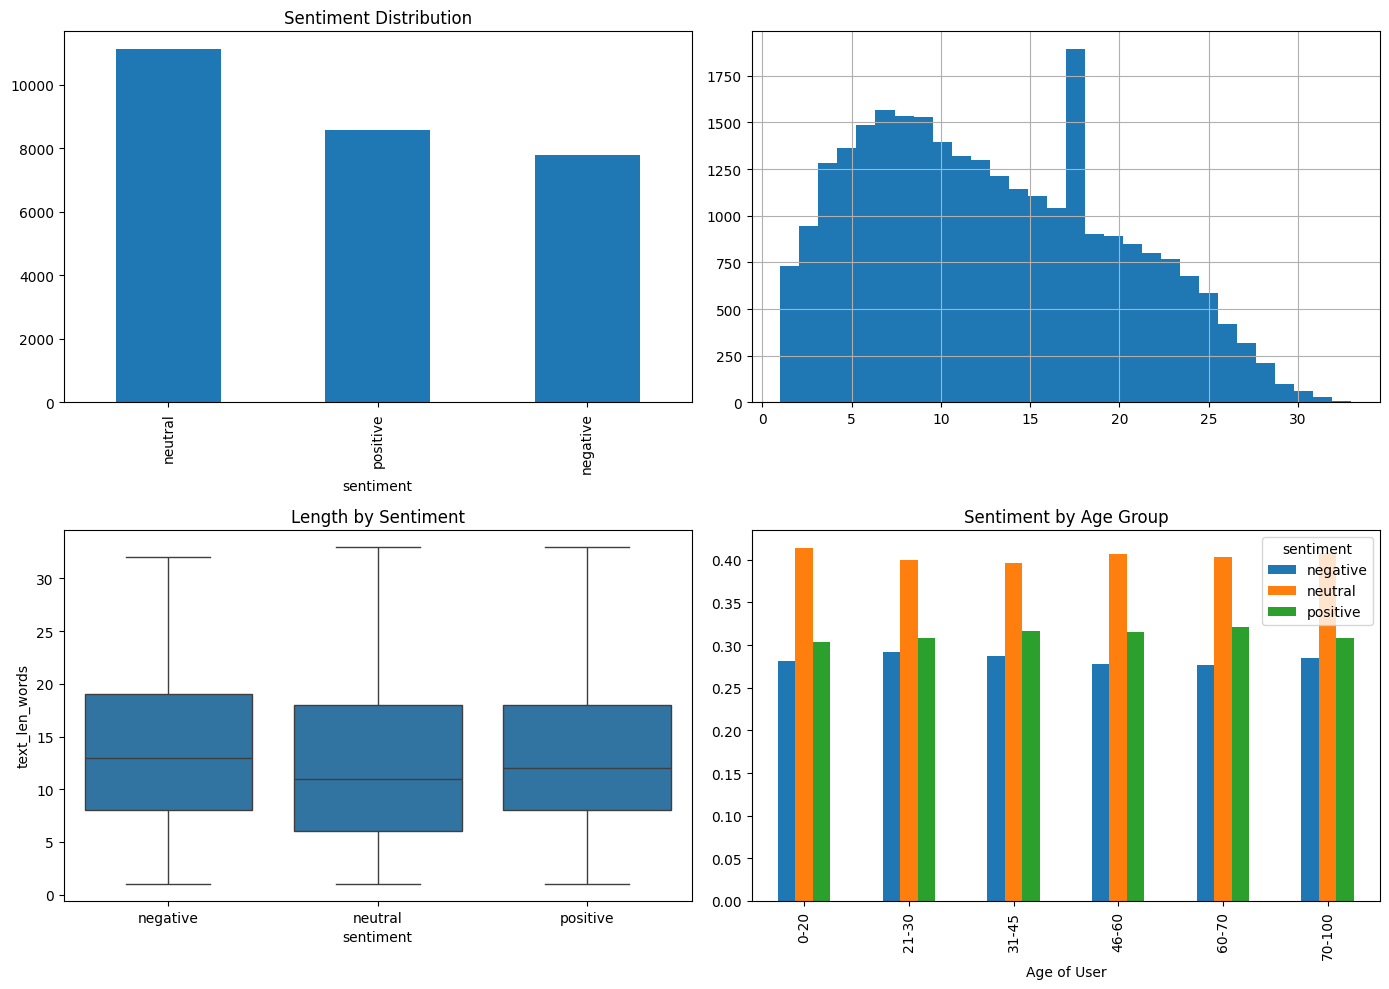

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns

fig, axes = plt.subplots(2,2, figsize = (14,10))

df['sentiment'].value_counts().plot(kind ='bar', ax = axes[0,0], title = 'Sentiment Distribution')
df['text_len_words'].hist(bins = 30, ax =axes[0,1])
sns.boxplot(data = df, x = 'sentiment', y = 'text_len_words', ax = axes[1,0])
axes[1,0].set_title("Length by Sentiment")

pd.crosstab(df['Age of User'], df['sentiment'], normalize ='index').plot(kind = 'bar', ax = axes[1,1])
axes[1,1].set_title("Sentiment by Age Group")

plt.tight_layout()
plt.show()


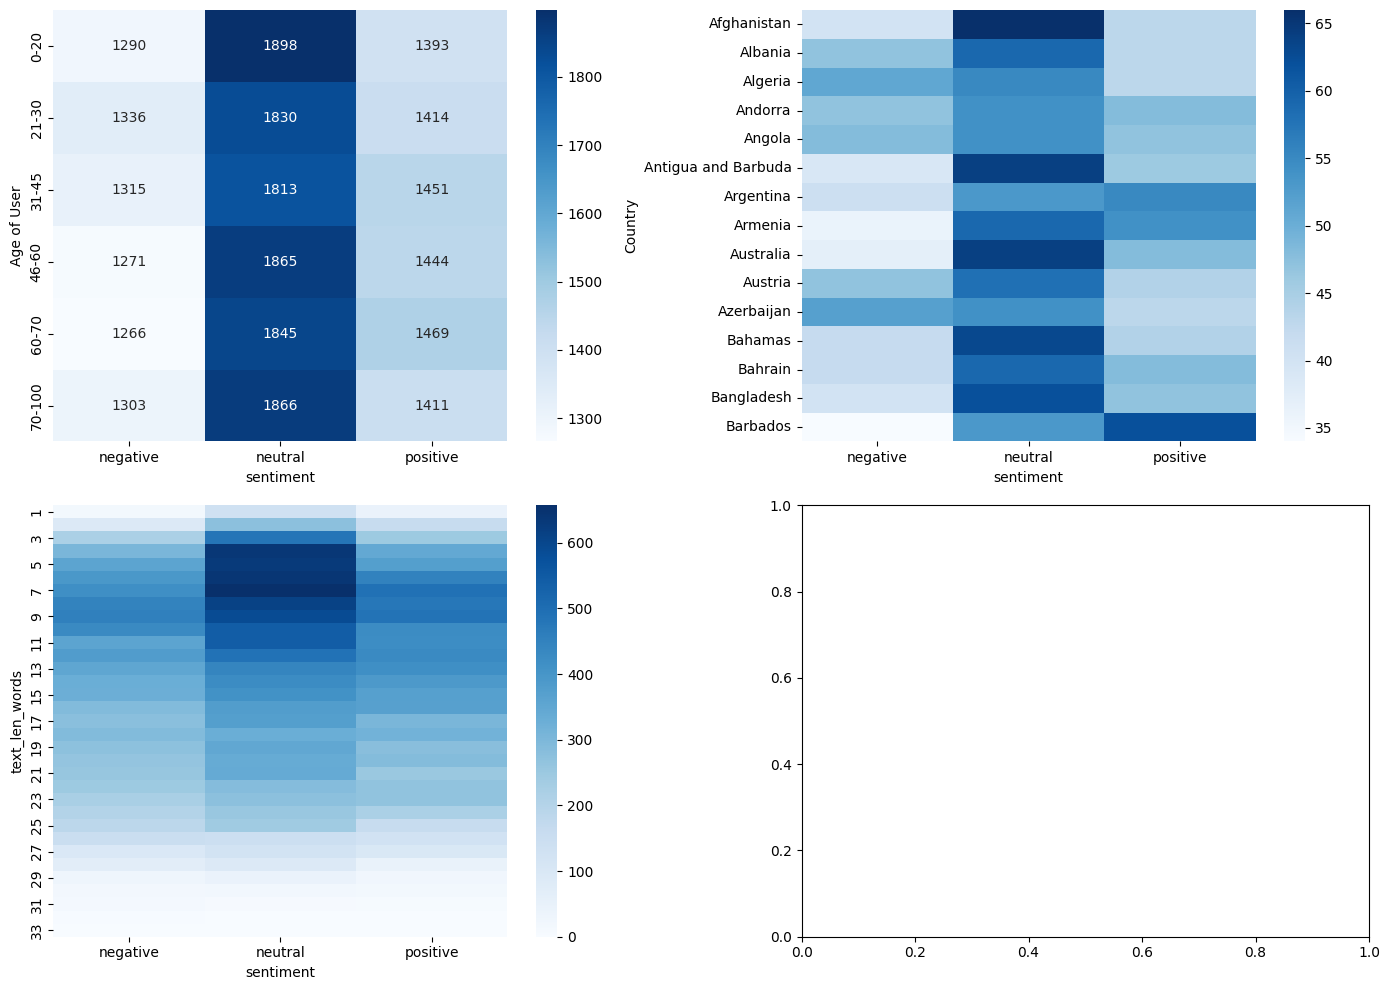

In [ ]:
fig, axes = plt.subplots(2,2, figsize = (14,10))

top_countries = df["Country"].value_counts().nlargest(15).index

df_filtered = df[df['Country'].isin(top_countries)]

sns.heatmap(pd.crosstab(df['Age of User'], df['sentiment']), annot=True, fmt='d', cmap="Blues", ax=axes[0, 0])
sns.heatmap(pd.crosstab(df_filtered['Country'], df_filtered['sentiment']), annot=False, fmt='d', cmap='Blues', ax=axes[0, 1])
sns.heatmap(pd.crosstab(df['text_len_words'], df['sentiment']),annot = False, fmt ='d', cmap = "Blues", ax=axes[1,0])
plt.tight_layout()
plt.show()

- **Feature Engineering**

In [ ]:
df['text_len_words'] = df['text'].str.split().str.len()
df['exclamation_count'] = df['text'].str.count('!')
df['upppercase_word_count'] = df['text'].apply(lambda x: sum(1 for w in x.split() if w.isupper()))

-  **Hypothesis Testing**

In [ ]:
from scipy.stats import chi2_contingency, f_oneway

#drop age user
contingency = pd.crosstab(df['Age of User'], df['sentiment'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-squared statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

#Keep the text_len_words /reject null hypothesis
groups = [df[df['sentiment'] == s]['text_len_words'] for s in df['sentiment'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"Anova p-value: {p_val:.4f}")

Chi-squared statistic: 8.0919
P-value: 0.6199
Anova p-value: 0.0000


In [ ]:
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment', 'Age of User',
       'Country', 'text_len_words', 'exclamation_count',
       'upppercase_word_count'],
      dtype='object')

In [ ]:
#drop country
contingency = pd.crosstab(df['Country'], df['sentiment'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"P-value: {p:.4f}")

#exclamation_count, keep
groups = [df[df['sentiment'] == s]['exclamation_count'] for s in df['sentiment'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"Anova p-value: {p_val:.4f}")

#uppercase word count
groups = [df[df['sentiment'] == s]['upppercase_word_count'] for s in df['sentiment'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"Anova p-value: {p_val:.4f}")


KeyError: 'Country'

In [ ]:
contingency = pd.crosstab(df['selected_text'], df['sentiment'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"P-value: {p:.4f}")

# **Building Model**

In [ ]:
df = df.drop(columns = ['Country', 'Age of User'])
df.columns

KeyError: "['Country', 'Age of User'] not found in axis"

In [ ]:
df.columns

Index(['textID', 'text', 'selected_text', 'sentiment', 'text_len_words',
       'exclamation_count', 'upppercase_word_count'],
      dtype='object')

In [ ]:
df = df.rename(columns ={'upppercase_word_count' : 'uppercase_word_count'})
print(df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment', 'text_len_words',
       'exclamation_count', 'uppercase_word_count'],
      dtype='object')


In [ ]:
df = df.drop(columns = ['selected_text'])

In [ ]:
df.text_len_words

,text_len_words
0,7
1,10
2,5
3,5
4,14
...,...
27476,16
27477,23
27478,22
27479,6


In [ ]:
df.columns

Index(['textID', 'text', 'sentiment', 'text_len_words', 'exclamation_count',
       'uppercase_word_count'],
      dtype='object')

Accuracy Score: 0.6761280931586608

               precision    recall  f1-score   support

    negative       0.66      0.65      0.66      1556
     neutral       0.64      0.65      0.65      2223
    positive       0.73      0.73      0.73      1717

    accuracy                           0.68      5496
   macro avg       0.68      0.68      0.68      5496
weighted avg       0.68      0.68      0.68      5496

[[1016  430  110]
 [ 426 1451  346]
 [  91  377 1249]]


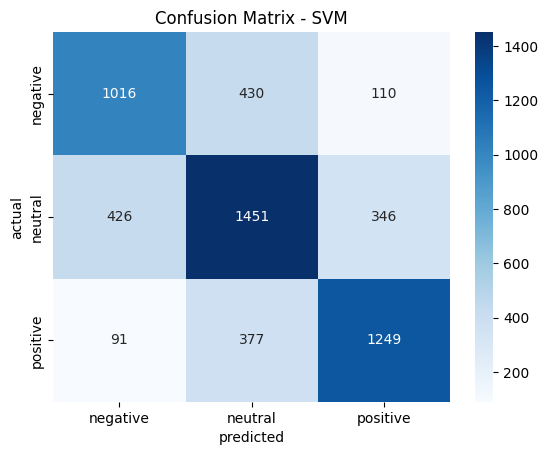

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

text_col = 'text'
numeric_cols  = ['text_len_words', "exclamation_count", "uppercase_word_count"]
target_col = 'sentiment'

X = df[[text_col] + numeric_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(max_features = 5000, stop_words = "english", ngram_range = (1,2)), text_col),
    ('num', StandardScaler(), numeric_cols)
    ])

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(C = 1.0, random_state = 42, class_weight = "balanced"))
])

svm_pipeline.fit(X_train, y_train)

y_pred = svm_pipeline.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\n", classification_report(y_test,y_pred))

cm = confusion_matrix(y_test, y_pred, labels = svm_pipeline.classes_)
print(cm )

sns.heatmap(cm, annot = True, fmt= 'd', cmap = "Blues",
            xticklabels = svm_pipeline.classes_,
            yticklabels = svm_pipeline.classes_
            )
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion Matrix - SVM")
plt.show()
